<a href="https://colab.research.google.com/github/ELOUAHABI1218/custumer-churn-ML-prjt/blob/main/Copie_de_Classification_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()
df["Churn"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,count
Churn,
No,5174
Yes,1869


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f"\nValeurs uniques dans {col} :")
    print(df[col].value_counts())


Valeurs uniques dans customerID :
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64

Valeurs uniques dans gender :
gender
Male      3555
Female    3488
Name: count, dtype: int64

Valeurs uniques dans Partner :
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Valeurs uniques dans Dependents :
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

Valeurs uniques dans PhoneService :
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

Valeurs uniques dans MultipleLines :
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

Valeurs uniques dans InternetService :
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

Valeurs uniques dans OnlineSecurity :
OnlineSecurity
No       

on remareque que on a 11 lignes vide en TotalCharges

In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


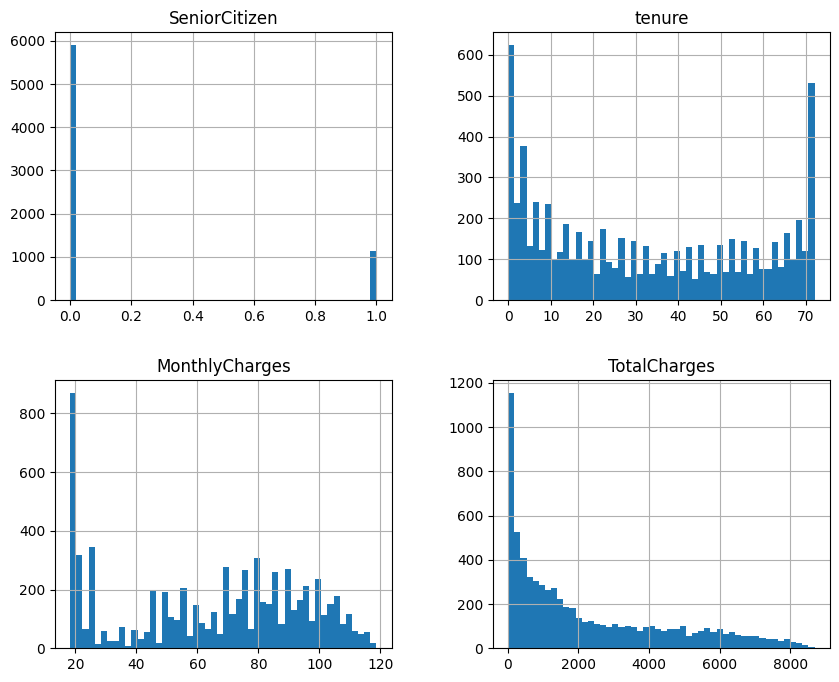

In [ ]:
import matplotlib.pyplot as plt
df.hist(bins=50,figsize=(10,8))
plt.show()

In [ ]:
df["Churn_num"] = df["Churn"].map({"No": 0, "Yes": 1})

In [ ]:
matrix_corr=df.corr(numeric_only=True)
matrix_corr["Churn_num"].sort_values(ascending=False)


,Churn_num
Churn_num,1.000000
MonthlyCharges,0.193356
SeniorCitizen,0.150889
TotalCharges,-0.199484
tenure,-0.352229


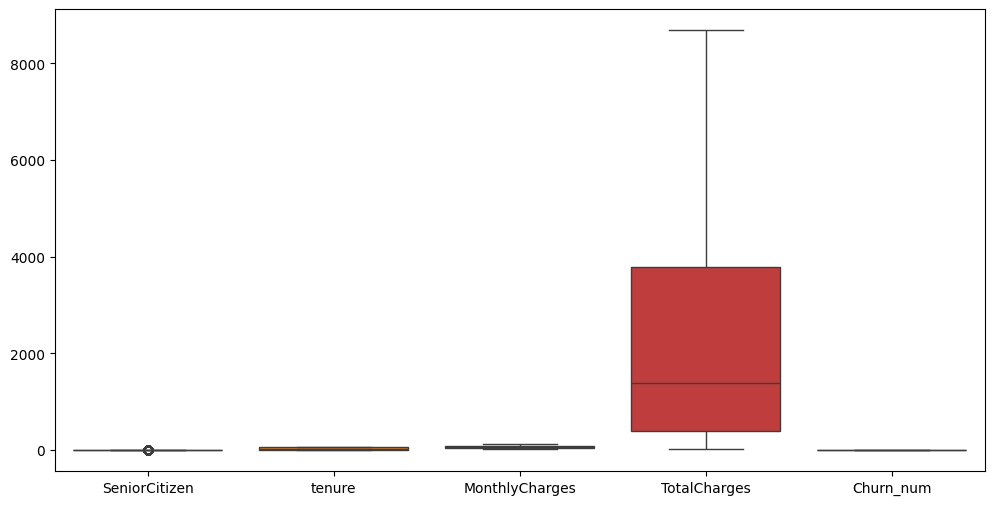

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(df)
plt.show()

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'Churn_num'],
      dtype='object')

In [ ]:
X = df.drop(["Churn", "Churn_num", "customerID"], axis=1)
y = df["Churn_num"]


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [ ]:
num_features = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_features = X_train.columns.difference(num_features).tolist()



In [ ]:
num_pipeline = Pipeline([
   ("imputer", SimpleImputer(strategy="median")),
   ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
   ("imputer", SimpleImputer(strategy="most_frequent")),
   ("onehot", OneHotEncoder(handle_unknown="ignore"))
])


In [ ]:
preprocessor = ColumnTransformer([
   ("num", num_pipeline, num_features),
   ("cat", cat_pipeline, cat_features)
])


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate

log_reg = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

In [ ]:
scoring =scoring=["accuracy", "precision", "recall", "f1", "roc_auc"]

cv_results_log = cross_validate(
    log_reg,
    X_train,
    y_train,
    cv=5,
    scoring=scoring
)

pd.DataFrame(cv_results_log).mean()


,0
fit_time,0.102485
score_time,0.061409
test_accuracy,0.804222
test_precision,0.657690
test_recall,0.548495
test_f1,0.597988
test_roc_auc,0.845601


In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree_clf = Pipeline([
    ("preprocessing", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

In [ ]:
cv_results_tree = cross_validate(
    tree_clf,
    X_train,
    y_train,
    cv=5,
    scoring=scoring
)

pd.DataFrame(cv_results_tree).mean()


,0
fit_time,0.085043
score_time,0.044887
test_accuracy,0.717250
test_precision,0.468252
test_recall,0.476254
test_f1,0.471847
test_roc_auc,0.640895


Matrice de confusion

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

In [ ]:
y_train_pred = cross_val_predict(log_reg, X_train, y_train, cv=5)

In [ ]:
cm = confusion_matrix(y_train, y_train_pred)
cm

array([[3711,  428],
       [ 675,  820]])

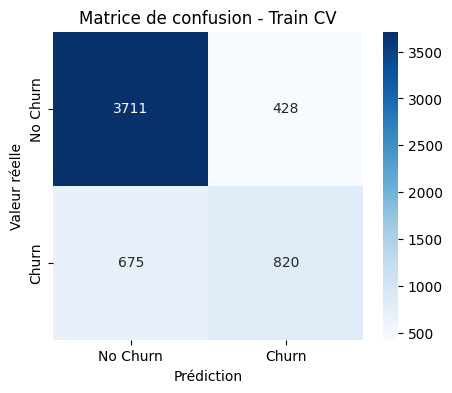

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.xlabel("Prédiction")
plt.ylabel("Valeur réelle")
plt.title("Matrice de confusion - Train CV")
plt.show()


Ajustement de seuil :recherche d'un seuil pour maximiser F1

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve, f1_score

# Obtenir les probabilités de la classe positive (churn)
y_scores = cross_val_predict(log_reg, X_train, y_train, cv=5, method="predict_proba")[:, 1]

# Calculer précision, rappel et seuils pour tous les seuils possibles
precisions, recalls, thresholds = precision_recall_curve(y_train, y_scores)

#  Calculer le F1-score pour chaque seuil
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)

#Trouver le seuil qui maximise le F1-score
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]
best_precision = precisions[best_idx]
best_recall = recalls[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Best Threshold: {best_threshold}")
print(f"Precision: {best_precision:.3f}")
print(f"Recall: {best_recall:.3f}")
print(f"F1 Score: {best_f1:.3f}")

# Faire des prédictions avec ce seuil
y_pred_balanced = (y_scores >= best_threshold)


Best Threshold: 0.320051166276606
Precision: 0.555
Recall: 0.746
F1 Score: 0.637


In [ ]:
from sklearn.metrics import confusion_matrix
cmNewSeuil=confusion_matrix(y_train, y_pred_balanced)
cmNewSeuil

array([[3245,  894],
       [ 379, 1116]])

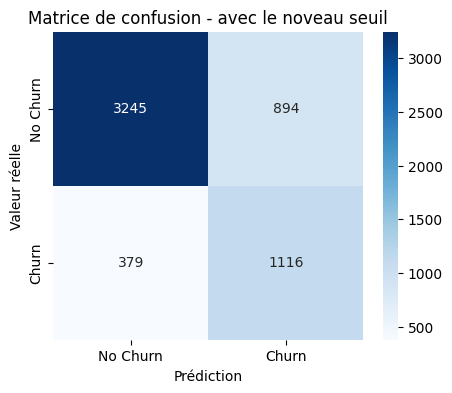

In [ ]:
p
lt.figure(figsize=(5,4))
sns.heatmap(cmNewSeuil, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.xlabel("Prédiction")
plt.ylabel("Valeur réelle")
plt.title("Matrice de confusion - avec le noveau seuil")
plt.show()

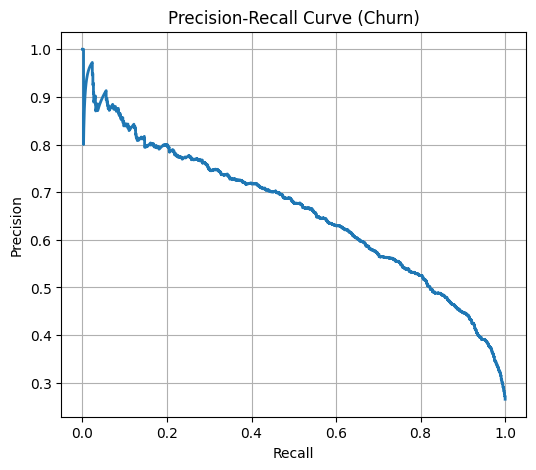

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Scores de probabilité (classe positive = churn)
y_scores = cross_val_predict(
    log_reg,
    X_train,
    y_train,
    cv=5,
    method="predict_proba"
)[:, 1]

# Courbe PR
precisions, recalls, thresholds = precision_recall_curve(y_train, y_scores)

plt.figure(figsize=(6, 5))
plt.plot(recalls, precisions, linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Churn)")
plt.grid()
plt.show()


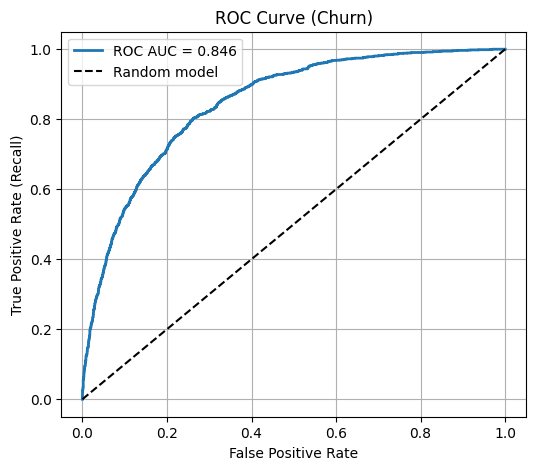

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds_roc = roc_curve(y_train, y_scores)
roc_auc = roc_auc_score(y_train, y_scores)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", label="Random model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve (Churn)")
plt.legend()
plt.grid()
plt.show()


RandomForest

Random Forest ROC AUC: 0.818534197506224


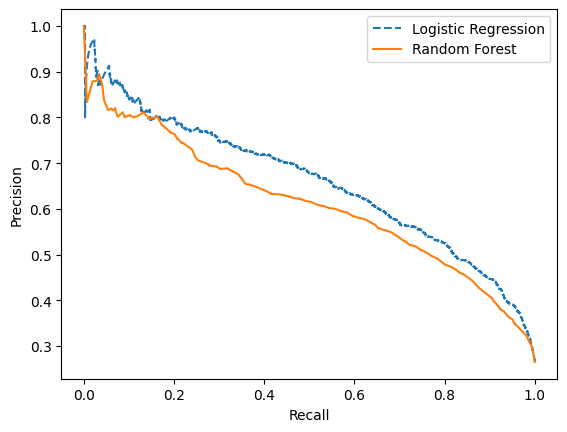

In [ ]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = Pipeline([('preprocessing', preprocessor),
                       ('clf', RandomForestClassifier(random_state=42))])

# Probabilités avec CV
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train, cv=5, method="predict_proba")[:,1]

# Courbe précision / rappel
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(y_train, y_probas_forest)

# Courbe ROC
fpr_f, tpr_f, thresholds_roc_f = roc_curve(y_train, y_probas_forest)
roc_auc_f = roc_auc_score(y_train, y_probas_forest)

print("Random Forest ROC AUC:", roc_auc_f)

# Plot PR curve pour comparer
plt.plot(recalls, precisions, "--", label="Logistic Regression")
plt.plot(recalls_forest, precisions_forest, "-", label="Random Forest")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(

        random_state=42,

    ))
])


In [ ]:
from sklearn.model_selection import cross_val_predict

y_scores_rf = cross_val_predict(
    rf_pipeline,
    X_train,
    y_train,
    cv=5,
    method="predict_proba"
)[:, 1]


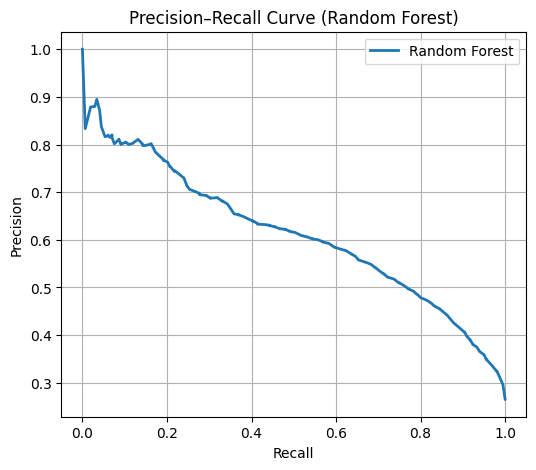

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

prec_rf, rec_rf, thr_rf = precision_recall_curve(y_train, y_scores_rf)

plt.figure(figsize=(6,5))
plt.plot(rec_rf, prec_rf, linewidth=2, label="Random Forest")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Random Forest)")
plt.legend()
plt.grid()
plt.show()


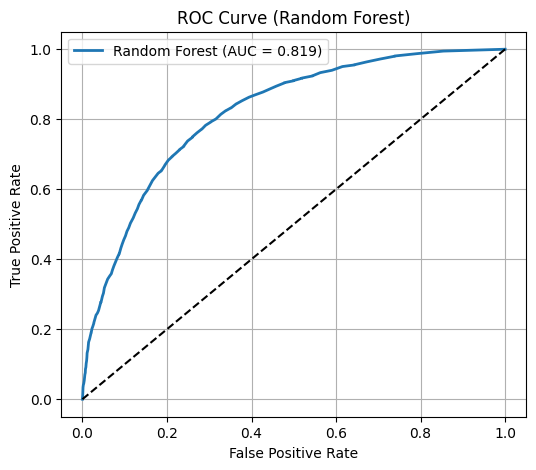

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_rf, tpr_rf, _ = roc_curve(y_train, y_scores_rf)
roc_auc_rf = roc_auc_score(y_train, y_scores_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr_rf, tpr_rf, linewidth=2,
         label=f"Random Forest (AUC = {roc_auc_rf:.3f})")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Random Forest)")
plt.legend()
plt.grid()
plt.show()


comparaison de randomForest et logReg

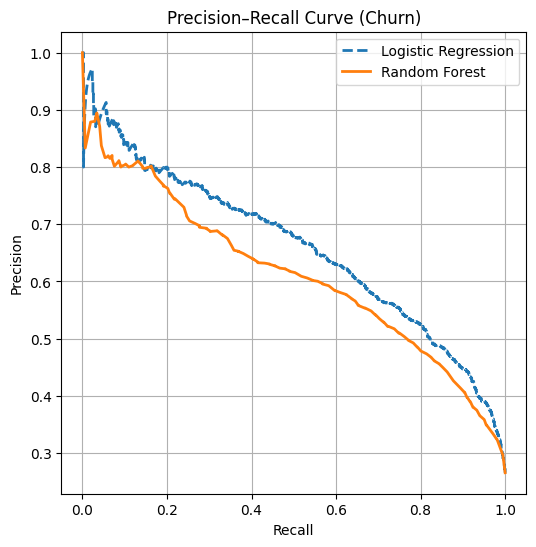

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Logistic Regression
prec_log, rec_log, _ = precision_recall_curve(y_train, y_scores)

# Random Forest
prec_rf, rec_rf, _ = precision_recall_curve(y_train, y_scores_rf)

plt.figure(figsize=(6,6))
plt.plot(rec_log, prec_log, "--", linewidth=2, label="Logistic Regression")
plt.plot(rec_rf, prec_rf, "-", linewidth=2, label="Random Forest")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Churn)")
plt.legend()
plt.grid()
plt.show()


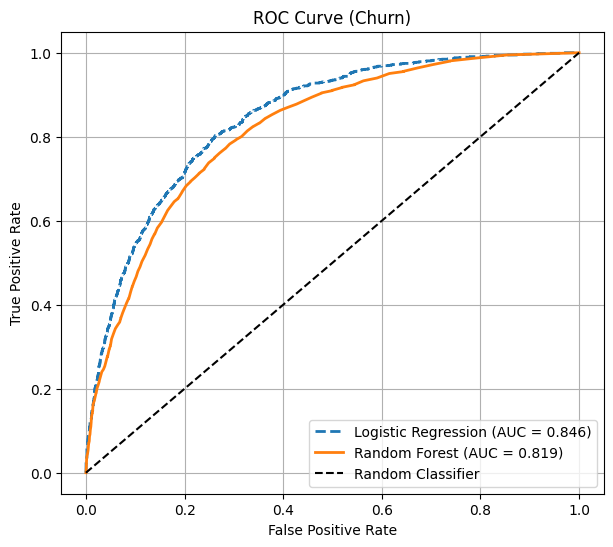

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_train, y_scores)
auc_log = roc_auc_score(y_train, y_scores)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_train, y_scores_rf)
auc_rf = roc_auc_score(y_train, y_scores_rf)

plt.figure(figsize=(7,6))
plt.plot(fpr_log, tpr_log, "--", linewidth=2,
         label=f"Logistic Regression (AUC = {auc_log:.3f})")
plt.plot(fpr_rf, tpr_rf, "-", linewidth=2,
         label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot([0,1], [0,1], "k--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Churn)")
plt.legend()
plt.grid()
plt.show()


In [ ]:
log_reg.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Contract', 'Dependents',
                                                   'DeviceProtection',
                                                   'InternetService',
                                                   'MultipleLines',
                                                   'OnlineBackup',
                                                   'OnlineSecurity',
                                                   'PaperlessBilling',
                                                   'Partner', 'PaymentMethod',
                                                   'PhoneService',
                                                   'SeniorCitizen',
                                                   'StreamingMovies',
                                                   'StreamingTV', 'TechSupport',
                                                   'gender'])])),
                ('model', LogisticRegression(max_iter=1000))])

test

In [ ]:
# Probabilités pour la classe positive sur le test set
y_pred = log_reg.predict(X_test)
y_test_proba =log_reg.predict_proba(X_test)[:, 1]

# Appliquer le seuil optimal
y_test_pred = (y_test_proba >= best_threshold).astype(int)


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, roc_auc_score

precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
accuracy = accuracy_score(y_test, y_test_pred)
roc_auc = roc_auc_score(y_test, y_test_proba)

print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")
print(f"ROC AUC: {roc_auc:.3f}")


Accuracy: 0.757
Precision: 0.531
Recall: 0.727
F1 Score: 0.614
ROC AUC: 0.842


In [ ]:
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[795 240]
 [102 272]]


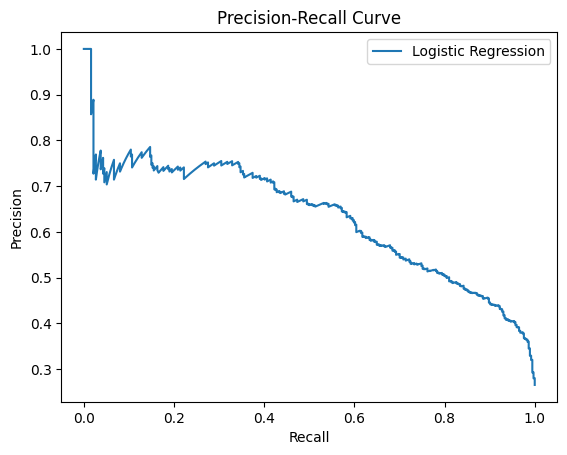

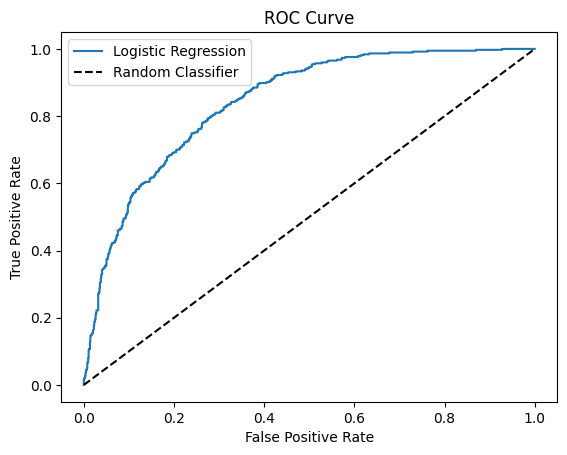

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve

# Precision-Recall
precisions, recalls, thresholds = precision_recall_curve(y_test, y_test_proba)
plt.plot(recalls, precisions, label="Logistic Regression")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

# ROC
fpr, tpr, thresholds_roc = roc_curve(y_test, y_test_proba)
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1], [0,1], "k--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
